In [ ]:
import pathlib

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

import openmc
import openmc.stats

# Nuclear data path - adjust as needed
# openmc.config['cross_sections'] = '/mnt/d/xs/openmc/endfb-vii.1-hdf5/cross_sections.xml'

RUN_DIR = pathlib.Path('test_source_energy_outputs')
RUN_DIR.mkdir(exist_ok=True)

ALPHA = 0.05

In [18]:
E_MIN = 1.0e6    # 1 MeV
E_PEAK = 7.0e6   # 7 MeV (peak)
E_MAX = 14.0e6   # 14 MeV
N_SOURCE_BINS = 200

source_energies = np.linspace(E_MIN, E_MAX, N_SOURCE_BINS + 1)
source_midpoints = 0.5 * (source_energies[:-1] + source_energies[1:])

def triangular_pdf(E, E_min, E_peak, E_max):
    """Triangular probability density function."""
    E = np.asarray(E)
    pdf = np.zeros_like(E, dtype=float)
    mask_left = (E >= E_min) & (E < E_peak)
    pdf[mask_left] = 2 * (E[mask_left] - E_min) / ((E_max - E_min) * (E_peak - E_min))
    mask_right = (E >= E_peak) & (E <= E_max)
    pdf[mask_right] = 2 * (E_max - E[mask_right]) / ((E_max - E_min) * (E_max - E_peak))
    return pdf

source_probs = triangular_pdf(source_midpoints, E_MIN, E_PEAK, E_MAX)

energy_dist = openmc.stats.Tabular(
    source_energies,
    np.append(source_probs, source_probs[-1]),  # Extend for histogram
    interpolation='histogram'
)

In [19]:
openmc.reset_auto_ids()

SPHERE_RADIUS = 5.0  # cm

sphere_surface = openmc.Sphere(r=SPHERE_RADIUS, boundary_type='vacuum')
vacuum_cell = openmc.Cell(name='vacuum', region=-sphere_surface)
universe = openmc.Universe(cells=[vacuum_cell])
geometry = openmc.Geometry(universe)
geometry.export_to_xml(path=RUN_DIR)

In [20]:
source = openmc.IndependentSource(
    space=openmc.stats.Point((0.0, 0.0, 0.0)),
    energy=energy_dist,
    angle=openmc.stats.Isotropic(),
    particle='neutron',
    strength=1.0
)

In [21]:
N_TALLY_BINS = 50
tally_energy_bins = np.linspace(E_MIN * 0.95, E_MAX * 1.05, N_TALLY_BINS + 1)

energy_filter = openmc.EnergyFilter(tally_energy_bins)
surface_filter = openmc.SurfaceFilter(sphere_surface)

spectrum_tally = openmc.Tally(name='energy_spectrum')
spectrum_tally.filters = [surface_filter, energy_filter]
spectrum_tally.scores = ['current']
spectrum_tally.higher_moments = True

tallies = openmc.Tallies([spectrum_tally])

In [22]:
PARTICLES_PER_BATCH = 10000
N_BATCHES = 100
TOTAL_PARTICLES = PARTICLES_PER_BATCH * N_BATCHES

settings = openmc.Settings()
settings.run_mode = 'fixed source'
settings.particles = PARTICLES_PER_BATCH
settings.batches = N_BATCHES
settings.seed = 42  # Reproducibility
settings.source = source
settings.output = {'tallies': False}

In [23]:
model = openmc.Model(geometry=geometry, settings=settings, tallies=tallies)
model.export_to_model_xml(path=RUN_DIR)

In [24]:
sp_path = model.run(cwd=RUN_DIR, output=False)

In [25]:
with openmc.StatePoint(sp_path) as sp:
    tally = sp.get_tally(name='energy_spectrum')
    tally_mean = tally.mean.flatten()
    tally_std = tally.std_dev.flatten()

tally_bin_edges = tally_energy_bins
tally_bin_centers = 0.5 * (tally_bin_edges[:-1] + tally_bin_edges[1:])
tally_bin_widths = np.diff(tally_bin_edges)

total_current = tally_mean.sum()
measured_pdf = tally_mean / (total_current * tally_bin_widths)
measured_pdf_std = tally_std / (total_current * tally_bin_widths)

In [26]:
expected_pdf = triangular_pdf(tally_bin_centers, E_MIN, E_PEAK, E_MAX)

expected_probs = expected_pdf * tally_bin_widths
expected_probs /= expected_probs.sum()

n_particles = TOTAL_PARTICLES
observed_counts = tally_mean * n_particles
expected_counts = expected_probs * n_particles

In [27]:
# TEST 1: 95% confidence interval coverage
z_95 = stats.norm.ppf(0.975)

ci_lower = measured_pdf - z_95 * measured_pdf_std
ci_upper = measured_pdf + z_95 * measured_pdf_std
within_ci = (expected_pdf >= ci_lower) & (expected_pdf <= ci_upper)

in_source_range = (tally_bin_centers >= E_MIN) & (tally_bin_centers <= E_MAX)
n_bins_in_range = in_source_range.sum()
n_within_ci = (within_ci & in_source_range).sum()
ci_coverage = n_within_ci / n_bins_in_range * 100

CI_PASS_THRESHOLD = 90.0
ci_test_pass = ci_coverage >= CI_PASS_THRESHOLD

In [28]:
# TEST 2: chi-square goodness-of-fit
valid_bins = (expected_counts > 5) & in_source_range
n_valid_bins = valid_bins.sum()

chi2_contributions = np.zeros_like(observed_counts)
chi2_contributions[valid_bins] = (
    (observed_counts[valid_bins] - expected_counts[valid_bins])**2
    / expected_counts[valid_bins]
)
chi2_stat = chi2_contributions[valid_bins].sum()

dof = n_valid_bins - 1
chi2_pvalue = 1 - stats.chi2.cdf(chi2_stat, dof)
chi2_test_pass = chi2_pvalue > ALPHA

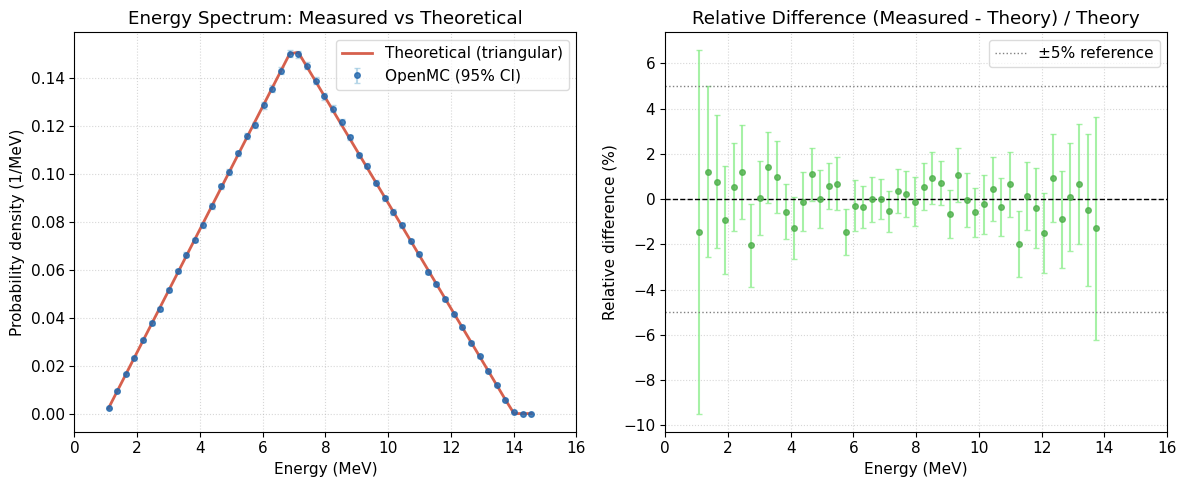

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

COLOR_DATA = '#2166ac'
COLOR_THEORY = '#d6604d'
COLOR_RESIDUAL = '#4daf4a'
COLOR_CI = '#a6cee3'

ax = axes[0]
ax.errorbar(tally_bin_centers / 1e6, measured_pdf * 1e6,
            yerr=z_95 * measured_pdf_std * 1e6,
            fmt='o', ms=4, color=COLOR_DATA, ecolor=COLOR_CI,
            capsize=2, label='OpenMC (95% CI)', alpha=0.8)
ax.plot(tally_bin_centers / 1e6, expected_pdf * 1e6,
        '-', color=COLOR_THEORY, lw=2, label='Theoretical (triangular)')
ax.set_xlabel('Energy (MeV)')
ax.set_ylabel('Probability density (1/MeV)')
ax.set_title('Energy Spectrum: Simulated vs Theoretical')
ax.legend()
ax.grid(True, ls=':', alpha=0.5)
ax.set_xlim(0, 16)

ax = axes[1]
with np.errstate(divide='ignore', invalid='ignore'):
    rel_diff = np.where(expected_pdf > 0,
                        (measured_pdf - expected_pdf) / expected_pdf * 100,
                        0)
    rel_diff_err = np.where(expected_pdf > 0,
                            measured_pdf_std / expected_pdf * 100,
                            0)

ax.errorbar(tally_bin_centers[in_source_range] / 1e6,
            rel_diff[in_source_range],
            yerr=z_95 * rel_diff_err[in_source_range],
            fmt='o', ms=4, color=COLOR_RESIDUAL, ecolor='lightgreen',
            capsize=2, alpha=0.8)
ax.axhline(0, color='k', ls='--', lw=1)
ax.axhline(5, color='gray', ls=':', lw=1, label='±5% reference')
ax.axhline(-5, color='gray', ls=':', lw=1)
ax.set_xlabel('Energy (MeV)')
ax.set_ylabel('Relative difference (%)')
ax.set_title('Relative Difference (Measured - Theory) / Theory')
ax.legend()
ax.grid(True, ls=':', alpha=0.5)
ax.set_xlim(0, 16)

fig.tight_layout()
plt.savefig('7224_ss_1.png', dpi=150, bbox_inches='tight')
plt.show()

In [30]:
# PASS if both CI coverage and chi-square goodness-of-fit criteria are met
overall_pass = chi2_test_pass and ci_test_pass

In [31]:
result = 'PASS' if overall_pass else 'FAIL'
with open('results.txt', 'w') as results_file:
    results_file.write(result + '\n')